# GLM-5.3-Flash on 4× CMP 170HX (3× x16 + 1× x1) — Morrowmake recipe, PP4

| Metric | Value |
|---|---:|
| Decode, 1 user (structured) | **131.3 tok/s** |
| Best aggregate (8 users, structured) | **595.2 tok/s** |
| Cold prefill (19–29k-token prompts) | **3,710 tok/s** |
| TTFT, 864-token prompt | **0.58 s** |

![decode vs Morrowmake](../assets/charts/2026-09-27-glm-5.3-flash-morrowmake-4card-pp4-vllm.png)

```bash
git clone https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe && cd glm53-flash-cmp170hx-recipe && git checkout v1.4.1
```

Evidence: [`results/2026-09-27-glm-5.3-flash-morrowmake-pp4-narrow-link/`](../results/2026-09-27-glm-5.3-flash-morrowmake-pp4-narrow-link/README.md) · upstream: [Morrowmake v1.4.1](https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe/tree/v1.4.1)

In [1]:
# --- Status cell ---
import os
EXPERIMENT = "2026-09-27-glm-5.3-flash-morrowmake-pp4-narrow-link"
RESULTS_DIR = "../results/" + EXPERIMENT
RECEIPTS = RESULTS_DIR + "/receipts"
LIVE = False  # True sends the final request to os.environ["GLM_URL"] (an OpenAI-compatible /v1 base)
GLM_URL = os.environ.get("GLM_URL", "http://127.0.0.1:8000/v1")
print("LIVE =", LIVE, "| receipts:", RECEIPTS)

LIVE = False | receipts: ../results/2026-09-27-glm-5.3-flash-morrowmake-pp4-narrow-link/receipts


In [2]:
# --- Helpers: receipt loader and table renderer ---
import json, csv, statistics
from IPython.display import display, Markdown

def receipt(*parts):
    with open("/".join([RECEIPTS, *parts])) as f:
        return json.load(f)

def table(header, rows):
    out = ["| " + " | ".join(header) + " |", "|" + "|".join("---:" if i else "---" for i in range(len(header))) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(out)))

## 1. TL;DR

- **Measured:** the Morrowmake v1.4.1 recipe runs unmodified in `LAYOUT=pp4` on a rig with one card on a Gen2 **x1** link. Smoke passes (chat + tool call), KV pool matches exactly.
- **Measured:** single-user decode is 7–12% under Morrowmake's x16 figures; 8-user aggregate is −4% to +10%; cold prefill is 41% lower.
- **Measured:** decode holds ~95 tok/s from 1k to 156k prompt tokens.
- **Inferred:** the prefill loss is the x1 hop into stage 3.

In [3]:
pins = {
    "recipe": "Morrowmake/glm53-flash-cmp170hx-recipe @ 1a516cc716 (v1.4.1)",
    "engine image": "ghcr.io/morrowmake/vllm-cmp170hx@sha256:14d7b380cc62…",
    "vLLM fork commit": "378c37b0098a41a5cd25b3bf8b56d158e33a6cbf",
    "target": "canada-quant/GLM-5.3-Flash-W4A16-MTP @ 5723f4d02a (W4A16)",
    "drafter": "incoai/GLM-5.3-Flash-DFlash2 @ bf582e4eac (k=3)",
    "driver / CUDA": "610.43.03 / 13.3",
    "topology": "PP4, links x16 / x16 / x16 / x1 (Gen2), P2P off, 180 W cap",
    "context": "262,144 tokens, KV pool 2,320,328",
}
table(["pin", "value"], pins.items())

| pin | value |
|---|---:|
| recipe | Morrowmake/glm53-flash-cmp170hx-recipe @ 1a516cc716 (v1.4.1) |
| engine image | ghcr.io/morrowmake/vllm-cmp170hx@sha256:14d7b380cc62… |
| vLLM fork commit | 378c37b0098a41a5cd25b3bf8b56d158e33a6cbf |
| target | canada-quant/GLM-5.3-Flash-W4A16-MTP @ 5723f4d02a (W4A16) |
| drafter | incoai/GLM-5.3-Flash-DFlash2 @ bf582e4eac (k=3) |
| driver / CUDA | 610.43.03 / 13.3 |
| topology | PP4, links x16 / x16 / x16 / x1 (Gen2), P2P off, 180 W cap |
| context | 262,144 tokens, KV pool 2,320,328 |

## 2. Results (measured)

Decode protocol: MiaAI-Lab `tests/bench_decode.py` @ 943912cd (the prompt source Morrowmake credits), T=0, thinking off, 400 tokens, median of 5. Two runs on separate server boots. Morrowmake column from their v1.4.1 README (4 × x16).

In [4]:
MORROWMAKE = {("structured", 1): 141.7, ("coding", 1): 138.4, ("prose", 1): 100.3,
              ("structured", 8): 542.3, ("coding", 8): 509.8, ("prose", 8): 383.6}
rows, data = [], {}
for c in (1, 8):
    for p in ("structured", "coding", "prose"):
        vals = []
        for run in ("run1", "run2"):
            d = receipt(run, f"decode-{p}-c{c}.json")
            vals.append(d["tok_s_median"] if c == 1 else d["aggregate_tok_s_median"])
        mm = MORROWMAKE[(p, c)]
        data[(p, c)] = vals
        rows.append([p, c, f"{vals[0]:.1f}", f"{vals[1]:.1f}", f"{mm:.1f}", f"{(vals[1] / mm - 1) * 100:+.0f}%"])
table(["prompt", "users", "run 1 tok/s", "run 2 tok/s", "Morrowmake x16", "Δ run 2"], rows)

| prompt | users | run 1 tok/s | run 2 tok/s | Morrowmake x16 | Δ run 2 |
|---|---:|---:|---:|---:|---:|
| structured | 1 | 130.7 | 131.3 | 141.7 | -7% |
| coding | 1 | 121.4 | 121.7 | 138.4 | -12% |
| prose | 1 | 88.7 | 89.0 | 100.3 | -11% |
| structured | 8 | 589.7 | 595.2 | 542.3 | +10% |
| coding | 8 | 490.2 | 489.0 | 509.8 | -4% |
| prose | 8 | 400.9 | 395.2 | 383.6 | +3% |

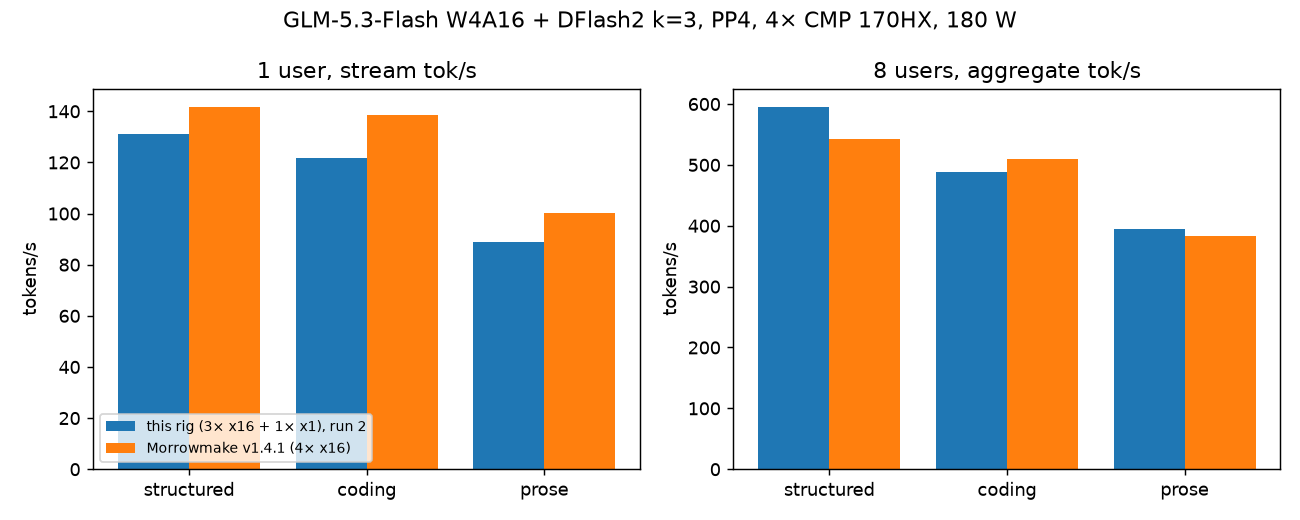

In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image

labels = ["structured", "coding", "prose"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, c, title in ((axes[0], 1, "1 user, stream tok/s"), (axes[1], 8, "8 users, aggregate tok/s")):
    x = range(len(labels))
    ax.bar([i - 0.2 for i in x], [data[(p, c)][1] for p in labels], 0.4, label="this rig (3× x16 + 1× x1), run 2")
    ax.bar([i + 0.2 for i in x], [MORROWMAKE[(p, c)] for p in labels], 0.4, label="Morrowmake v1.4.1 (4× x16)")
    ax.set_xticks(list(x), labels); ax.set_title(title); ax.set_ylabel("tokens/s")
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle("GLM-5.3-Flash W4A16 + DFlash2 k=3, PP4, 4× CMP 170HX, 180 W")
fig.tight_layout()
os.makedirs("../assets/charts", exist_ok=True)
fig.savefig("../assets/charts/%s.png" % '2026-09-27-glm-5.3-flash-morrowmake-4card-pp4-vllm', dpi=130); fig.savefig("../assets/charts/%s.svg" % '2026-09-27-glm-5.3-flash-morrowmake-4card-pp4-vllm')
plt.close(fig)
Image("../assets/charts/%s.png" % '2026-09-27-glm-5.3-flash-morrowmake-4card-pp4-vllm')

In [6]:
pf = receipt("run1", "prefill-cold.json")["results"]
warm = pf[1:]  # first request = JIT warmup, excluded
table(["prompt tokens", "TTFT s", "prefill tok/s"], [[r["prompt_tokens"], f"{r['ttft_s']:.2f}", f"{r['prefill_tok_s']:,.0f}"] for r in pf])
print(f"median prefill (excluding warmup row 1): {statistics.median(r['prefill_tok_s'] for r in warm):,.0f} tok/s  | Morrowmake PP4: 6,254 tok/s on 24-38k prompts")

| prompt tokens | TTFT s | prefill tok/s |
|---|---:|---:|
| 19178 | 25.57 | 750 |
| 19446 | 5.40 | 3,603 |
| 28663 | 7.57 | 3,788 |
| 20805 | 5.61 | 3,710 |
| 27358 | 7.11 | 3,849 |
| 27104 | 9.25 | 2,931 |

median prefill (excluding warmup row 1): 3,710 tok/s  | Morrowmake PP4: 6,254 tok/s on 24-38k prompts


In [7]:
lc = receipt("run1", "longctx-decode.json")["results"]
table(["prompt tokens", "TTFT s", "decode tok/s"], [[r["prompt_tokens"], f"{r['ttft_s']:.1f}", f"{r['decode_tok_s']:.1f}"] for r in lc])

| prompt tokens | TTFT s | decode tok/s |
|---|---:|---:|
| 864 | 0.6 | 94.4 |
| 6117 | 2.2 | 83.7 |
| 25359 | 6.7 | 85.8 |
| 52446 | 13.1 | 102.7 |
| 106353 | 30.9 | 95.6 |
| 155934 | 41.0 | 94.8 |

In [8]:
rows = list(csv.DictReader(open(RECEIPTS + "/run2/telemetry.csv"), skipinitialspace=True))
peak = lambda k: max(float(r[k].split()[0]) for r in rows)
table(["telemetry (run 2, 1 s samples)", "peak"], [
    ["core °C", peak("temperature.gpu")], ["memory °C", peak("temperature.memory")],
    ["power.draw W (limit 180)", peak("power.draw [W]")],
    ["links (gpu:width)", ", ".join(sorted({f"{r['index']}:x{r['pcie.link.width.current']}" for r in rows}))]])
print(open(RECEIPTS + "/run2/xid.txt").read().strip())

| telemetry (run 2, 1 s samples) | peak |
|---|---:|
| core °C | 66.0 |
| memory °C | 75.0 |
| power.draw W (limit 180) | 271.41 |
| links (gpu:width) | 0:x16, 1:x16, 2:x16, 3:x1 |

XID=0


## 3. Reproduce

Hardware: 4 × CMP 170HX exposing 65,536 MiB each (the recipe preflight stops under 60 GiB), forced-air cooling, ~200 GB free disk for weights plus ~20 GB for the image. PP4 tolerates narrow links; TP4 needs all four on x16.

```bash
git clone https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe && cd glm53-flash-cmp170hx-recipe
git checkout v1.4.1
printf 'LAYOUT=pp4\nMODELS_DIR=/path/to/models\n' > .env
./install.sh          # pulls the pinned engine image
./download.sh         # target ~178 GiB + drafter ~2.2 GiB
./start.sh            # 20 min cold boot here, 11 min with warm kernel caches
./start.sh smoke
```

Bench: clone MiaAI-Lab's repo at 943912cd, set `BASE`/`MODEL` in `tests/bench_decode.py` to the server, then run [`run_decode.sh`](../results/2026-09-27-glm-5.3-flash-morrowmake-pp4-narrow-link/run_decode.sh) and [`bench_long.py`](../results/2026-09-27-glm-5.3-flash-morrowmake-pp4-narrow-link/bench_long.py) from the results folder.

## Try your own prompt

Edit `PROMPT`; with `LIVE = False` this prints the recorded structured run's response and usage instead.

In [9]:
PROMPT = "Count from 1 to 200. Output only the numbers, separated by spaces. No other text."
if LIVE:
    import urllib.request
    body = {"model": "glm-5.3-flash", "messages": [{"role": "user", "content": PROMPT}], "max_tokens": 400, "temperature": 0}
    req = urllib.request.Request(GLM_URL + "/chat/completions", json.dumps(body).encode(), {"Content-Type": "application/json"})
    resp = json.load(urllib.request.urlopen(req, timeout=600))
    print(resp["choices"][0]["message"]["content"]); print(resp["usage"])
else:
    run = receipt("run2", "decode-structured-c1.json")["runs"][0]
    print(run["text"][:400]); print(run["usage"])

The user wants me to count from 1 to 200, outputting only the numbers separated by spaces, with no other text. This is a straightforward request. Let me generate the numbers 1 through 200 separated by spaces.1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 
{'prompt_tokens': 33, 'total_tokens': 433, 'completion_tokens': 400, 'completion_tokens_details': {'reasoning_tokens': 0}}


<details><summary>Appendix</summary>

- **Thinking off leaks reasoning (measured).** With `chat_template_kwargs.enable_thinking=false`, the model still writes its reasoning, inline in `content`, which the `glm47` parser cannot separate. Thinking on (the recipe default) returns clean `content` plus a separate `reasoning` field. The decode benchmark follows MiaAI-Lab and Morrowmake with thinking off; token counts come from `usage` either way.
- **Boot time (measured).** 1,225 s cold. Weights load at ~1.07 GB/s from a virtual disk; the x1 stage loads 44 GiB ~100 s slower and finishes graph capture ~4.5 min after the others; kernel JIT adds ~5 min on the first start only (645 s with warm caches).
- **Power (measured).** `nvidia-smi` reported power.draw peaks above the 180 W limit (max 271 W in 1 s samples). Recorded as read; not investigated.
- **Not tested:** TP4 on this rig, prefill on 24–38k prose prompts, a `VLLM_PP_LAYER_PARTITION` that shrinks the x1 stage, contexts above 156k.
- **Licences:** recipe MIT; drafter CC BY-NC-ND 4.0 (research/evaluation only; `SPEC_MODE=mtp` avoids it); MiaAI-Lab bench AGPL-3.0, referenced by commit, not vendored.

</details>